# Обучение AutoGluon Quantile Regression

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:

from autogluon.tabular import TabularPredictor
import os

/opt/miniconda3/envs/ag/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка исходных данных (с новыми признаками)

In [5]:
train = pd.read_csv('/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/train_selected.csv')
train.head(5)

,AvgIpc,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRLOW,BCUT2D_MWHI,BCUT2D_MWLOW,BalabanJ,Charge_Asymmetry,Chi_Complexity,Chi_to_RingCount,...,fr_phenol,fr_piperzine,fr_quatN,fr_sulfide,fr_unbrch_alkane,fr_urea,qed,pIC50,pCC50,log10_SI
0,2.471240,-2.203512,2.178787,0.155539,32.166506,10.291948,2.063714,0.241070,2.590056,2.162989,...,0,0,0,1,0,0,0.681165,0.989639,1.018827,-0.029188
1,2.314947,-2.449813,2.456783,-0.003171,35.495692,9.631497,2.157249,0.155411,3.202665,5.979250,...,0,0,0,0,0,0,0.769122,4.353274,2.075665,2.277609
2,2.579710,-2.562182,2.584438,-0.007335,16.507764,9.486685,1.480238,0.332383,3.271705,3.649563,...,0,0,0,0,0,0,0.612606,2.352816,1.300287,1.052529
3,3.101827,-2.040425,2.409619,-0.384432,32.227747,10.102030,2.026965,0.162038,4.970214,5.111900,...,0,0,0,0,0,0,0.345823,2.165714,0.165714,2.000000
4,1.787472,-2.547053,2.539193,0.000365,14.788664,9.531931,1.940004,0.308846,3.002350,1.657054,...,0,0,0,0,0,0,0.562066,2.698264,1.154893,1.543371


In [7]:
test = pd.read_csv('/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/test_selected.csv')
test.head(5)

,AvgIpc,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRLOW,BCUT2D_MWHI,BCUT2D_MWLOW,BalabanJ,Charge_Asymmetry,Chi_Complexity,Chi_to_RingCount,...,fr_ketone_Topliss,fr_methoxy,fr_nitro,fr_phenol,fr_piperzine,fr_quatN,fr_sulfide,fr_unbrch_alkane,fr_urea,qed
0,3.494848,-2.425359,2.544663,-0.147725,32.166547,9.704289,1.531269,0.173188,3.264259,3.565174,...,0,0,0,0,0,0,1,0,0,0.770057
1,2.752143,-2.390353,2.369524,-0.277225,16.707906,9.991346,1.885708,0.269334,4.373269,2.230052,...,0,0,0,3,0,0,0,0,0,0.278628
2,2.001545,-2.580818,2.603245,-0.063729,14.717158,9.477838,1.911265,0.320711,3.081114,2.190560,...,0,0,0,0,0,0,0,0,0,0.657472
3,3.093791,-2.378300,2.497185,-0.343838,19.431747,9.748466,2.061305,0.161809,4.035225,4.196103,...,1,0,0,0,0,0,0,0,0,0.564307
4,2.896060,-2.201773,2.471778,-0.097822,16.731298,9.952325,1.940561,0.093867,3.310435,2.390479,...,1,0,0,0,0,0,0,0,0,0.696213


In [8]:
print(train.shape)
print(test.shape)

(751, 113)
(250, 110)


In [9]:
# ==========================================
# 1. НАСТРОЙКИ ДЛЯ ОДНОГО ТАРГЕТА
# ==========================================
target = 'pCC50'
other_targets = ['pIC50', 'log10_SI']

save_path = '/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/log_models_pCC50'
quantile_levels = [0.1, 0.5, 0.9, 0.95]

print(f"\n{'='*50}")
print(f"Обучение AutoGluon для таргета: {target}")
print(f"{'='*50}")

# 1) Удаляем другие таргеты
train_data_target = train.drop(columns=other_targets, errors='ignore').copy()

print("train_data_target shape:", train_data_target.shape)
print("Количество признаков:", train_data_target.shape[1] - 1)
print("Quantile levels:", quantile_levels)

# ==========================================
# 2. СОЗДАЕМ ПРЕДИКТОР ДЛЯ QUANTILE REGRESSION
# ==========================================
predictor = TabularPredictor(
    label=target,
    path=os.path.join(save_path, f"model_{target}_quantile"),
    problem_type='quantile',
    quantile_levels=quantile_levels
)

# ==========================================
# 3. ЗАПУСКАЕМ ОБУЧЕНИЕ
# ==========================================
predictor.fit(
    train_data=train_data_target,
    presets='best_quality',
    time_limit=1800,
    calibrate=True,
    feature_prune_kwargs={'force_prune': True},
    num_bag_folds=5,
    num_bag_sets=1,
    num_stack_levels=1,
    keep_only_best=True
)

print(f"Обучение quantile-модели для таргета {target} завершено.")

Verbosity: 2 (Standard Logging)



Обучение AutoGluon для таргета: pCC50
train_data_target shape: (751, 111)
Количество признаков: 110
Quantile levels: [0.1, 0.5, 0.9, 0.95]


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jul 14 11:30:34 PDT 2025; root:xnu-11417.140.69~1/RELEASE_ARM64_T8103
CPU Count:          8
Pytorch Version:    2.8.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       2.75 GB / 8.00 GB (34.3%)
Disk Space Avail:   29.76 GB / 228.27 GB (13.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=5, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stac

Обучение quantile-модели для таргета pCC50 завершено.


In [10]:
# 1. Оценка качества на кросс-валидации (OOF)
print(f"\n--- Результаты кросс-валидации для {target} ---")
leaderboard = predictor.leaderboard(silent=True)
print(leaderboard[['model', 'score_val', 'fit_time']])

print(f"\n Лучшая модель: {predictor.model_best}")


--- Результаты кросс-валидации для pCC50 ---
                         model  score_val   fit_time
0          WeightedEnsemble_L3  -0.102673  51.223613
1       ExtraTrees_r172_BAG_L2  -0.103620  45.023024
2            LightGBMXT_BAG_L2  -0.105485  48.938959
3       ExtraTrees_r172_BAG_L1  -0.106316   2.153730
4      RandomForest_r15_BAG_L1  -0.108933   3.779602
5          LightGBM_r30_BAG_L1  -0.109309   8.002403
6   NeuralNetTorch_r143_BAG_L1  -0.109802  14.246801
7          CatBoost_r49_BAG_L1  -0.112901   9.567576
8  NeuralNetFastAI_r111_BAG_L1  -0.115921   5.007995

 Лучшая модель: WeightedEnsemble_L3


In [11]:
# Предсказание pCC50 на тесте
print("\nГенерация предсказаний pСC50 для тестового набора...")
pred_test_quantiles_pCC50 = predictor.predict(test) 
print(pred_test_quantiles_pCC50.head())
print(pred_test_quantiles_pCC50.columns)


Генерация предсказаний pСC50 для тестового набора...
       0.10      0.50      0.90      0.95
0  0.226436  0.925070  1.526416  1.787248
1  0.104309  0.498432  1.016207  1.198025
2  0.345962  0.552786  1.170377  1.332406
3  0.108289  0.569452  1.327016  1.588176
4  0.157853  0.488996  1.070736  1.266263
Index([0.1, 0.5, 0.9, 0.95], dtype='float64')


In [12]:
# 1. Узнаем точное имя лучшей модели
best_model_name = predictor.model_best
print(f" Лучшая модель: {best_model_name}\n")

# 2. Достаем всё досье на эту модель
model_details = predictor.model_info(best_model_name)

# 3. Смотрим, какие базовые модели в нее вошли (и с какими весами)
print(" Веса базовых моделей в ансамбле:")
# Если это ансамбль, у него есть ключ 'children_info' или 'stacker_info'
if 'children_info' in model_details:
    # Выводим веса (какая модель внесла наибольший вклад)
    weights = model_details['children_info']['S1F1']['model_weights']
    for model, weight in weights.items():
        if weight > 0: # Показываем только те, что реально используются
            print(f"  - {model}: {weight:.4f}")

# 4. Выводим гиперпараметры самого ансамбля
print("\n Гиперпараметры лучшей модели:")
print(model_details['hyperparameters'])

 Лучшая модель: WeightedEnsemble_L3

 Веса базовых моделей в ансамбле:
  - NeuralNetTorch_r143_BAG_L1: 0.1176
  - LightGBMXT_BAG_L2: 0.2941
  - ExtraTrees_r172_BAG_L2: 0.5882

 Гиперпараметры лучшей модели:
{'use_orig_features': False, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}


In [13]:
# Заново достаем информацию о лучшем ансамбле
best_model_name = predictor.model_best
model_details = predictor.model_info(best_model_name)

print(" Гиперпараметры базовых моделей, вошедших в ансамбль:\n")

if 'children_info' in model_details:
    weights = model_details['children_info']['S1F1']['model_weights']
    
    # Проходимся по каждой модели, которая получила вес больше 0
    for base_model, weight in weights.items():
        if weight > 0:
            print(f" Модель: {base_model} (Вес: {weight:.4f})")
            # Извлекаем досье на конкретную базовую модель
            base_info = predictor.model_info(base_model)
            print("Параметры:", base_info['hyperparameters'])
            print("-" * 50)

 Гиперпараметры базовых моделей, вошедших в ансамбль:

 Модель: NeuralNetTorch_r143_BAG_L1 (Вес: 0.1176)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}
--------------------------------------------------
 Модель: LightGBMXT_BAG_L2 (Вес: 0.2941)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}
--------------------------------------------------
 Модель: ExtraTrees_r172_BAG_L2 (Вес: 0.5882)
Параметры: {'use_orig_features': True, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_s

In [14]:
best_model_name = predictor.model_best
model_details = predictor.model_info(best_model_name)

print(" ИСТИННЫЕ гиперпараметры алгоритмов:\n")

if 'children_info' in model_details:
    weights = model_details['children_info']['S1F1']['model_weights']
    
    for base_model, weight in weights.items():
        if weight > 0:
            print(f" Модель: {base_model} (Вес: {weight:.4f})")
            base_info = predictor.model_info(base_model)
            
            # Вскрываем обертку _BAG и берем параметры модели из первого фолда (S1F1)
            if 'children_info' in base_info and 'S1F1' in base_info['children_info']:
                real_params = base_info['children_info']['S1F1']['hyperparameters']
                print("Настоящие параметры:", real_params)
            else:
                print("Настоящие параметры:", base_info.get('hyperparameters', 'Не найдены'))
            print("-" * 50)

 ИСТИННЫЕ гиперпараметры алгоритмов:

 Модель: NeuralNetTorch_r143_BAG_L1 (Вес: 0.1176)
Настоящие параметры: {'num_epochs': 1000, 'epochs_wo_improve': None, 'activation': 'elu', 'embedding_size_factor': 1.0, 'embed_exponent': 0.56, 'max_embedding_dim': 100, 'y_range': None, 'y_range_extend': 0.05, 'dropout_prob': 0.1703783780377607, 'optimizer': 'adam', 'learning_rate': 0.0004107199833213839, 'weight_decay': 1.105439140660822e-07, 'proc.embed_min_categories': 4, 'proc.impute_strategy': 'median', 'proc.max_category_levels': 100, 'proc.skew_threshold': 0.99, 'use_ngram_features': False, 'num_layers': 5, 'hidden_size': 212, 'max_batch_size': 512, 'use_batchnorm': True, 'loss_function': 'auto', 'gamma': 5.0, 'alpha': 0.01, 'seed_value': 0}
--------------------------------------------------
 Модель: LightGBMXT_BAG_L2 (Вес: 0.2941)
Настоящие параметры: {'learning_rate': 0.05, 'extra_trees': True, 'seed': 0}
--------------------------------------------------
 Модель: ExtraTrees_r172_BAG_L2 (В

In [15]:
# 1. Берем только q50 и q90 для pCC50
pred_q50 = pred_test_quantiles_pCC50[0.50]
pred_q90 = pred_test_quantiles_pCC50[0.90]

# 2. Обратное преобразование из pIC50 -> IC50, mM
pred_CC50_q50_mM = 1000 * np.power(10, -pred_q50)
pred_CC50_q90_mM = 1000 * np.power(10, -pred_q90)

# 3. Собираем в DataFrame
preds_df_CC50 = pd.DataFrame({
    "CC50_q50_mM": pred_CC50_q50_mM,
    "CC50_q90_mM": pred_CC50_q90_mM
})

# 4. Сохранение
save_filename = "/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/preds_CC50_q50_q90.csv"
preds_df_CC50.to_csv(save_filename, index=False)

print(f"Файл {save_filename} успешно сохранен!")
print(preds_df_CC50.head())

Файл /Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/Models_log_ag/preds_CC50_q50_q90.csv успешно сохранен!
   CC50_q50_mM  CC50_q90_mM
0   118.831200    29.756618
1   317.371613    96.337090
2   280.036102    67.549706
3   269.493317    47.096001
4   324.342896    84.969742


In [16]:
preds_df_CC50.describe()

,CC50_q50_mM,CC50_q90_mM
count,250.000000,250.000000
mean,534.057739,144.493225
std,486.073212,184.537460
min,9.711527,0.865193
25%,174.127129,29.267148
50%,398.675858,73.442417
75%,722.280624,155.414509
max,2742.582031,920.452087


In [17]:
train_first = pd.read_csv('/Users/irinaryzova/Desktop/ДПО_МИФИ/Хакатон/train.csv')
train.head()

,AvgIpc,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_MRLOW,BCUT2D_MWHI,BCUT2D_MWLOW,BalabanJ,Charge_Asymmetry,Chi_Complexity,Chi_to_RingCount,...,fr_phenol,fr_piperzine,fr_quatN,fr_sulfide,fr_unbrch_alkane,fr_urea,qed,pIC50,pCC50,log10_SI
0,2.471240,-2.203512,2.178787,0.155539,32.166506,10.291948,2.063714,0.241070,2.590056,2.162989,...,0,0,0,1,0,0,0.681165,0.989639,1.018827,-0.029188
1,2.314947,-2.449813,2.456783,-0.003171,35.495692,9.631497,2.157249,0.155411,3.202665,5.979250,...,0,0,0,0,0,0,0.769122,4.353274,2.075665,2.277609
2,2.579710,-2.562182,2.584438,-0.007335,16.507764,9.486685,1.480238,0.332383,3.271705,3.649563,...,0,0,0,0,0,0,0.612606,2.352816,1.300287,1.052529
3,3.101827,-2.040425,2.409619,-0.384432,32.227747,10.102030,2.026965,0.162038,4.970214,5.111900,...,0,0,0,0,0,0,0.345823,2.165714,0.165714,2.000000
4,1.787472,-2.547053,2.539193,0.000365,14.788664,9.531931,1.940004,0.308846,3.002350,1.657054,...,0,0,0,0,0,0,0.562066,2.698264,1.154893,1.543371


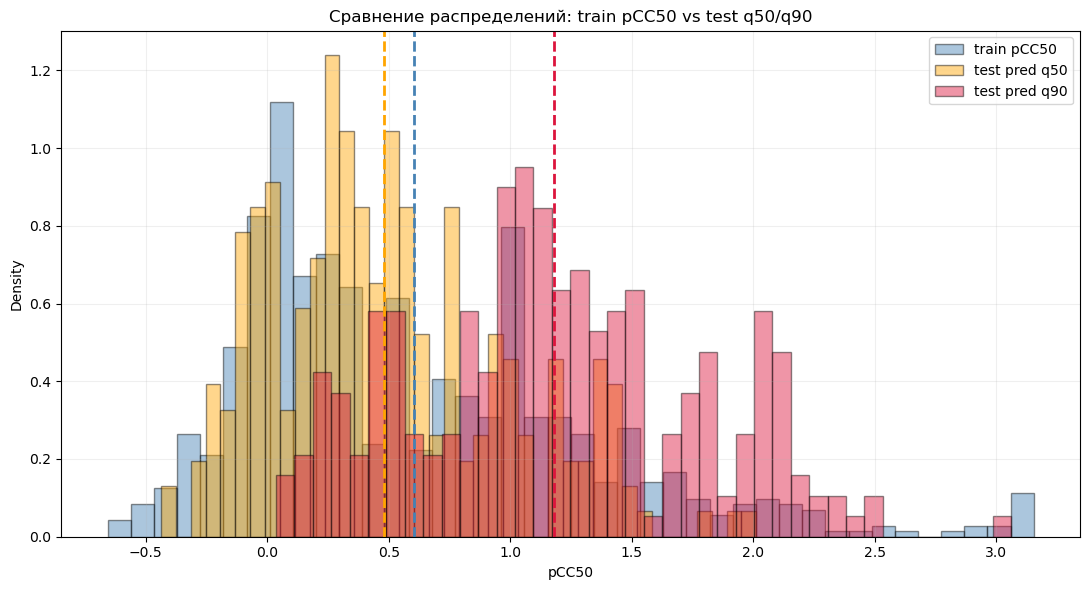

In [18]:
# логарифмический таргет train
train_pсc50 = train["pCC50"].dropna()

# логарифмические предсказания квантилей на test
pred_q50 = pred_test_quantiles_pCC50[0.50]
pred_q90 = pred_test_quantiles_pCC50[0.90]

plt.figure(figsize=(11, 6))

# train
plt.hist(
    train_pсc50,
    bins=40,
    alpha=0.45,
    label="train pCC50",
    color="steelblue",
    edgecolor="black",
    density=True
)

# q50
plt.hist(
    pred_q50,
    bins=40,
    alpha=0.45,
    label="test pred q50",
    color="orange",
    edgecolor="black",
    density=True
)

# q90
plt.hist(
    pred_q90,
    bins=40,
    alpha=0.45,
    label="test pred q90",
    color="crimson",
    edgecolor="black",
    density=True
)

# вертикальные линии средних
plt.axvline(train_pсc50.mean(), color="steelblue", linestyle="--", linewidth=2)
plt.axvline(pred_q50.mean(), color="orange", linestyle="--", linewidth=2)
plt.axvline(pred_q90.mean(), color="crimson", linestyle="--", linewidth=2)

plt.title("Сравнение распределений: train pCC50 vs test q50/q90")
plt.xlabel("pCC50")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

По графику видно, что распределение предсказаний `q50` для `pCC50` ближе к обучающему распределению и лучше описывает его центральную часть. В то же время распределение `q90` заметно смещено вправо, что указывает на более высокие прогнозируемые значения и акцент на верхнем хвосте распределения.

Таким образом, `q50` можно рассматривать как более сбалансированный и устойчивый вариант прогноза, тогда как `q90` отражает верхний сценарий и может приводить к переоценке высоких значений `pCC50`.